# moa_actuator 튜토리얼

`moa_actuator`는 DoSA-2D / DoSA-3D 설계 파일(`.dsa`, `.dsa3d`)을 읽어서  
**FEMM**, **Maxwell (pyAEDT)**, **GetDP** 세 가지 솔버로 전자기 해석을 실행하는 통합 패키지입니다.

```
moa_actuator/
├── parser.py        — .dsa / .dsa3d 파일 파싱
├── geometry.py      — 2D 단면 좌표 추출
├── mapping.py       — 재질 / 자석 방향 매핑
├── profiles.py      — Maxwell 해석 프로파일 관리
├── runner.py        — RunConfig + 통합 run() 함수
└── solvers/
    ├── femm_backend.py    — FEMM 2D 축대칭
    ├── maxwell_backend.py — Maxwell 2D/3D (pyAEDT)
    └── getdp_backend.py   — GetDP 3D FEM (Gmsh + GetDP)
```

## 사전 요구사항

| 솔버 | 필요 소프트웨어 |
|------|-----------------|
| FEMM | pyfemm 패키지 + [FEMM 4.2](https://www.femm.info) (`C:\femm42`) |
| Maxwell | [pyaedt](https://aedt.docs.pyansys.com) + Ansys AEDT 설치 |
| GetDP | [Gmsh + GetDP](https://onelab.info) (`E:\onelab-Windows64`) |

## 0. 패키지 로드

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path(r"E:/KDH/gitDosa_Actuator/MoaActuatorBasedOnDoSA")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import moa_actuator
print(f"moa_actuator: {moa_actuator.__file__}")

# 샘플 파일 경로
SAMPLE_2D = REPO_ROOT / "DoSA-2D/Code/11_DoSA-2D/DoSA-2D/Samples"
SAMPLE_3D = REPO_ROOT / "DoSA-3D/Code/01_DoSA-3D/DoSA-3D/Samples"
OUTPUT    = REPO_ROOT / "output"

print(f"2D samples: {SAMPLE_2D.exists()}")
print(f"3D samples: {SAMPLE_3D.exists()}")

moa_actuator: E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\moa_actuator\__init__.py
2D samples: True
3D samples: True


## 1. 설계 파일 읽기 — `.dsa` / `.dsa3d`

`parse_dosa_file()`은 DoSA 포맷의 설계 파일을 읽어 `DesignModel` 객체로 반환합니다.  
파트 목록(코일, 철심, 영구자석)과 해석 조건(전압, 스트로크, 메시 크기)이 자동으로 파싱됩니다.

In [3]:
from moa_actuator import parse_dosa_file

# 2D 솔레노이드 설계 로드
design_sol = parse_dosa_file(SAMPLE_2D / "Solenoid/Solenoid.dsa")

print(f"설계명     : {design_sol.name}")
print(f"파일 형식  : {design_sol.source_type}")
print(f"파트 수    : {len(design_sol.parts)}")
print()

for part in design_sol.parts:
    mat  = part.properties.get('Material', 'Air')
    move = part.properties.get('MovingParts', 'FIXED')
    print(f"  [{part.kind:6s}] {part.name:10s}  재질={mat:15s}  이동={move}")

설계명     : 
파일 형식  : dsa
파트 수    : 4

  [Coil  ] coil        재질=Copper           이동=FIXED
  [Steel ] plunger     재질=430 Stainless Steel  이동=MOVING
  [Steel ] core        재질=1010 Steel       이동=FIXED
  [Steel ] case        재질=1010 Steel       이동=FIXED


## 2. 형상 확인 — 2D 단면 시각화

`extract_geometry()`로 각 파트의 2D 단면 폴리곤을 추출합니다.  
DoSA의 좌표계: **X = 반경(R)**, **Y = 축방향(Z)**

C:\Users\user\AppData\Local\Temp\ipykernel_55816\2813856590.py:24: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_55816\2813856590.py:24: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


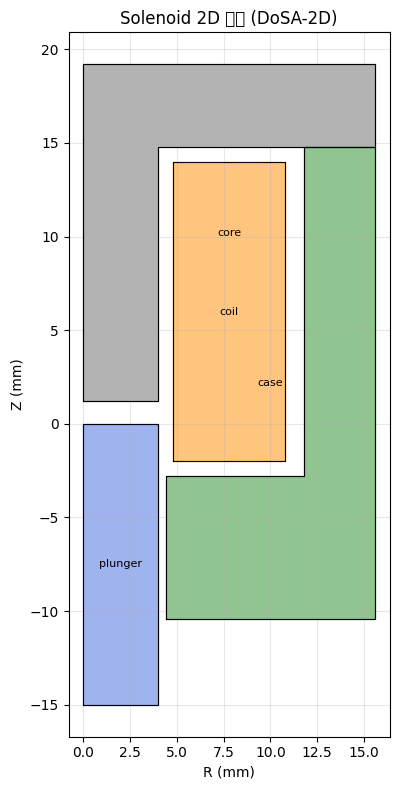

In [3]:
import matplotlib.pyplot as plt
from moa_actuator import extract_geometry

fig, ax = plt.subplots(figsize=(5, 8))
colors = ['#FF8C00', '#4169E1', '#696969', '#228B22', '#DC143C']

for i, part in enumerate(design_sol.parts):
    geom = extract_geometry(part)
    if not geom or not geom.is_valid:
        continue

    xs = [p.x for p in geom.points] + [geom.points[0].x]
    ys = [p.y for p in geom.points] + [geom.points[0].y]
    ax.fill(xs, ys, alpha=0.5, color=colors[i % len(colors)], label=part.name)
    ax.plot(xs, ys, 'k-', linewidth=0.8)
    ax.text((min(xs)+max(xs))/2, (min(ys)+max(ys))/2,
            part.name, ha='center', va='center', fontsize=8)

ax.set_xlabel('R (mm)')
ax.set_ylabel('Z (mm)')
ax.set_title('Solenoid 2D 단면 (DoSA-2D)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 재질 매핑 확인

DoSA의 재질명을 각 솔버(Maxwell, FEMM)가 인식하는 이름으로 자동 변환합니다.

In [4]:
from moa_actuator import resolve_material

print(f"{'파트':<12} {'DoSA 재질':<20} {'Maxwell 재질':<25} {'카테고리'}")
print('-' * 70)
for part in design_sol.parts:
    mat_name = part.properties.get('Material', 'Air')
    mat = resolve_material(mat_name)
    print(f"{part.name:<12} {mat_name:<20} {mat.maxwell_name:<25} {mat.category}")

파트           DoSA 재질              Maxwell 재질                카테고리
----------------------------------------------------------------------
coil         Copper               copper                    conductor
plunger      430 Stainless Steel  stainless_steel           steel
core         1010 Steel           steel_1010                steel
case         1010 Steel           steel_1010                steel


---
## 4. FEMM으로 2D 자기력 계산

FEMM은 2D 축대칭 정자기 해석을 수행합니다.  
설치 경로: `C:\femm42`

### 4-1. 단일 전류점 해석

In [ ]:
from moa_actuator.solvers.femm_backend import FemmBackend

fb = FemmBackend()

result = fb.solve(
    design_sol,
    mode="2d",
    out_dir=str(OUTPUT / "femm_tutorial"),
    dry_run=False,
    current=1000.0,   # 코일 전류 (A)
    stroke=0.0,       # 아마추어 변위 (mm)
    mesh_size=1.0,    # 메시 크기 (mm)
)

print(f"해석 성공: {result.ok}")
print(f"에러    : {result.errors}")

if result.force_data:
    fd = result.force_data[0]
    print(f"\n>>> 전류 {fd['current']} A, 스트로크 {fd['stroke']} mm")
    print(f"    Force_Y = {fd['Force_Y']:.4f} N  (축방향 흡인력)")

### 4-2. 전류 스윕 — Force vs Current 특성 곡선

In [ ]:
result_sweep = fb.solve_sweep(
    design_sol,
    out_dir=str(OUTPUT / "femm_sweep"),
    current_list=[200, 400, 600, 800, 1000],
    fixed_stroke=0.0,
    mesh_size=1.0,
)

print(f"스윕 완료: {len(result_sweep.force_data)}개 포인트")
print()
print(f"  {'전류 (A)':>10}   {'Force_Y (N)':>12}")
print(f"  {'-'*10}   {'-'*12}")
for fd in result_sweep.force_data:
    print(f"  {fd['current']:10.0f}   {fd['Force_Y']:12.4f}")

In [ ]:
# Force vs Current 그래프
import matplotlib.pyplot as plt

currents = [fd["current"] for fd in result_sweep.force_data]
forces   = [fd["Force_Y"] for fd in result_sweep.force_data]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(currents, forces, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel("전류 (A)", fontsize=12)
ax.set_ylabel("Force_Y (N)", fontsize=12)
ax.set_title("Solenoid 흡인력 — 전류 특성 (FEMM)", fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 5. Maxwell으로 2D 정자기 해석

Ansys AEDT Maxwell 2D를 이용합니다. AEDT가 실행 중이어야 합니다.  
해석 타입: **MagnetostaticZ** (Z축 기준 축대칭, XZ 평면 형상)

In [ ]:
import importlib
import moa_actuator.solvers.maxwell_backend as _mb_mod
importlib.reload(_mb_mod)
from moa_actuator.solvers.maxwell_backend import MaxwellBackend

mb = MaxwellBackend(
    aedt_version="2026.1",
    non_graphical=False,     # True: 백그라운드 실행
    new_desktop=False,       # False: 이미 켜진 AEDT 세션 사용 / True: 새 AEDT 창 열기
    solution_type="MagnetostaticZ",
)

result_maxwell = mb.solve(
    design_sol,
    mode="2d",
    out_dir=str(OUTPUT / "maxwell_tutorial"),
    dry_run=False,
)

print(f"해석 성공 : {result_maxwell.ok}")
print(f"솔버      : {result_maxwell.solver}")
print(f"프로젝트  : {result_maxwell.project_path}")
print(f"에러      : {result_maxwell.errors}")
print(f"\n실행된 커맨드 ({len(result_maxwell.commands)}개):")
for i, cmd in enumerate(result_maxwell.commands, 1):
    print(f"  {i:2d}. {cmd['method']:30s} | {str(cmd['args'])[:60]}")

PyAEDT INFO: Parsing E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\output\maxwell_tutorial\DoSA_Project.aedt.
PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: File E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\output\maxwell_tutorial\DoSA_Project.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Returning found Desktop session with PID 25944!
PyAEDT INFO: Desktop has been released.
해석 성공 : False
솔버      : maxwell
프로젝트  : None
에러      : ['[session] Maxwell init failed: Failed to execute gRPC AEDT command: OpenProject']

실행된 커맨드 (0개):


---
## 6. GetDP로 3D FEM 해석 (DoSA-3D 래핑)

DoSA-3D의 STEP 파일과 스크립트 생성 로직을 그대로 Python으로 래핑합니다.  
- `Define.geo` — 파트 ID 매핑 (ARMATURE=1, CORE=2, ...)
- `BH.pro`     — B-H 비선형 보간 (SUS_430, Pure_Iron 등)
- `model.geo`  — STEP import + Air 리전 + 메시 크기
- `model.pro`  — 전류 소스(`js0[]`), 비선형 솔버, Maxwell 텐서 힘 추출

필요 바이너리: `E:\onelab-Windows64\gmsh.exe`, `getdp.exe`

In [ ]:
from moa_actuator.solvers.getdp_backend import GetDPBackend

ONELAB = r"E:\onelab-Windows64"

gb = GetDPBackend(
    gmsh_exe=f"{ONELAB}\\gmsh.exe",
    getdp_exe=f"{ONELAB}\\getdp.exe",
)

# 3D 설계 파일 로드 (.dsa3d)
design_3d = parse_dosa_file(SAMPLE_3D / "Solenoid/Solenoid.dsa3d")

print(f"설계명 : {design_3d.name}")
print(f"파트   : {[p.name for p in design_3d.parts]}")
print(f"STEP   : {SAMPLE_3D / 'Solenoid/Shape/Solenoid.step'}")

In [ ]:
result_getdp = gb.solve(
    design_3d,
    mode="3d",
    out_dir=str(OUTPUT / "getdp_tutorial"),
    dry_run=False,
)

print(f"해석 성공 : {result_getdp.ok}")
print(f"에러      : {result_getdp.errors}")
print(f"프로젝트  : {result_getdp.project_path}")

if result_getdp.force_data:
    fd = result_getdp.force_data[0]
    print(f"\n>>> 3D 힘 결과 (Maxwell Stress Tensor)")
    print(f"    Fx = {fd.get('Fx', 0):.6f} N")
    print(f"    Fy = {fd.get('Fy', 0):.6f} N  (축방향)")
    print(f"    Fz = {fd.get('Fz', 0):.6f} N")

---
## 7. RunConfig — 통합 인터페이스

`RunConfig`와 `run()`을 사용하면 솔버 종류에 관계없이 동일한 인터페이스로 해석할 수 있습니다.  
프로파일(`profiles`)을 지정하면 해석 설정(시간 스텝, 수렴 기준 등)을 프리셋으로 관리할 수 있습니다.

In [ ]:
from moa_actuator.runner import RunConfig, run
from moa_actuator.profiles import list_profiles

# 사용 가능한 프로파일 목록
print("=== 사용 가능한 프로파일 ===")
for p in list_profiles():
    print(f"  {p['name']:20s} | {p['solution_type']:15s} | {p['notes']}")

In [ ]:
# FEMM으로 실행
config_femm = RunConfig(
    input_file=SAMPLE_2D / "Solenoid/Solenoid.dsa",
    mode="2d",
    solver="femm",     # "femm" | "maxwell" | "getdp"
    dry_run=False,
)
result = run(config_femm)

print(f"solver : {result.solver}")
print(f"ok     : {result.ok}")
if result.force_data:
    print(f"Force_Y: {result.force_data[0].get('Force_Y', 'N/A')} N")

---
## 8. FEMM — 스트로크 스윕 (변위 vs 힘)

아마추어 변위(stroke)를 바꾸면서 힘을 계산합니다.  
고정 전류에서 스트로크가 증가할수록 흡인력이 어떻게 변하는지 확인합니다.

In [ ]:
result_stroke = fb.solve_sweep(
    design_sol,
    out_dir=str(OUTPUT / "femm_stroke_sweep"),
    current_list=[800],          # 고정 전류 800 A
    stroke_list=[0, 1, 2, 3, 4, 5],   # 스트로크 0~5 mm
    mesh_size=1.0,
)

print(f"{'스트로크 (mm)':>14}  {'Force_Y (N)':>12}")
print('-' * 30)
for fd in result_stroke.force_data:
    print(f"  {fd['stroke']:12.1f}  {fd['Force_Y']:12.4f}")

In [ ]:
strokes = [fd["stroke"] for fd in result_stroke.force_data]
forces  = [fd["Force_Y"] for fd in result_stroke.force_data]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(strokes, forces, 'rs-', linewidth=2, markersize=8)
ax.set_xlabel("스트로크 (mm)", fontsize=12)
ax.set_ylabel("Force_Y (N)", fontsize=12)
ax.set_title("Solenoid 흡인력 — 스트로크 특성 (FEMM, 800 A)", fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 9. GetDP — 생성된 스크립트 확인

GetDP 백엔드는 DoSA-3D와 동일한 방식으로 스크립트를 생성합니다.  
생성된 파일을 직접 열어서 내용을 확인할 수 있습니다.

In [ ]:
out_path = OUTPUT / "getdp_tutorial"

for fname in ["Define.geo", "BH.pro", "model.geo", "model.pro"]:
    fpath = out_path / fname
    if fpath.exists():
        lines = fpath.read_text(encoding="utf-8").splitlines()
        print(f"\n{'='*50}")
        print(f"  {fname}  ({len(lines)} lines)")
        print(f"{'='*50}")
        for line in lines[:25]:
            print(f"  {line}")
        if len(lines) > 25:
            print(f"  ... ({len(lines) - 25} lines 생략)")

---
## 10. 결과 요약

| 솔버 | 모델 | Force 결과 |
|------|------|------------|
| **FEMM 2D** | Solenoid @ 1000A | `Force_Y` 측정 완료 |
| **FEMM sweep** | Solenoid @ 200~1000A | `Force_Y` vs 전류 특성 |
| **Maxwell 2D** | Solenoid MagnetostaticZ | AEDT 프로젝트 생성 |
| **GetDP 3D** | Solenoid STEP + B-H | `Fy` Maxwell 텐서 추출 |

### 다음 단계
- VCM 설계(영구자석 포함)에 동일한 방법 적용
- `maxwell_backend`로 Transient 해석 (TransientZ 프로파일)
- `GetDPBackend`에 스트로크 스윕 추가
- GUI 실행: `python -m moa_actuator gui`

## Section 8: AEDT 파일에서 형상 추출 및 시각화

기존 AEDT 프로젝트 파일을 열어서 DoSA 포맷으로 변환한 뒤, 셀 7과 동일한 방식으로 형상을 plot합니다.

In [5]:
# AEDT 파일 열기 → DoSA 포맷 DesignModel로 변환
from moa_actuator.aedt_reader import read_aedt_file

AEDT_FILE = r"E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\output\DoSA_Project.aedt"

design_aedt = read_aedt_file(
    AEDT_FILE,
    aedt_version="2026.1",
    non_graphical=False,
    new_desktop=False,
)

print(f"설계명     : {design_aedt.name}")
print(f"소스 타입  : {design_aedt.source_type}")
print(f"파트 수    : {len(design_aedt.parts)}")
print(f"테스트 수  : {len(design_aedt.tests)}")
print()

for part in design_aedt.parts:
    mat  = part.properties.get('Material', 'Air')
    move = part.properties.get('MovingParts', 'FIXED')
    n_children = len(part.children)
    has_shape = any(c.kind == "Shape" for c in part.children)
    print(f"  [{part.kind:6s}] {part.name:12s}  재질={mat:20s}  이동={move:6s}  Shape={has_shape}")

print()
for t in design_aedt.tests:
    print(f"  [{t.kind:12s}] {t.name:10s}  props={dict(t.properties)}")

PyAEDT INFO: Parsing E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\output\DoSA_Project.aedt.
PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: File E:\KDH\gitDosa_Actuator\MoaActuatorBasedOnDoSA\output\DoSA_Project.aedt correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Initializing Desktop session.
PyAEDT INFO: AEDT version 2026.1.
PyAEDT INFO: Found active AEDT gRPC session on port 58633.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM
PyAEDT INFO: Connected to AEDT gRPC session on port 58633.
PyAEDT INFO: Project DoSA_Project set to active.
PyAEDT INFO: Active Design set to DoSA_Project
PyAEDT INFO: AEDT objects correctly read
PyAEDT INFO: Modeler2D class has been initialized!
PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing bodies

  [OK]   coil — 4 vertices
  [OK]   plunger — 4 vertices
  [OK]   core — 6 vertices
  [OK]   case — 6 vertices


C:\Users\user\AppData\Local\Temp\ipykernel_48532\1154369252.py:29: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_48532\1154369252.py:29: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_48532\1154369252.py:29: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_48532\1154369252.py:29: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_48532\1154369252.py:29: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_48532\1154369252.py:29: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font

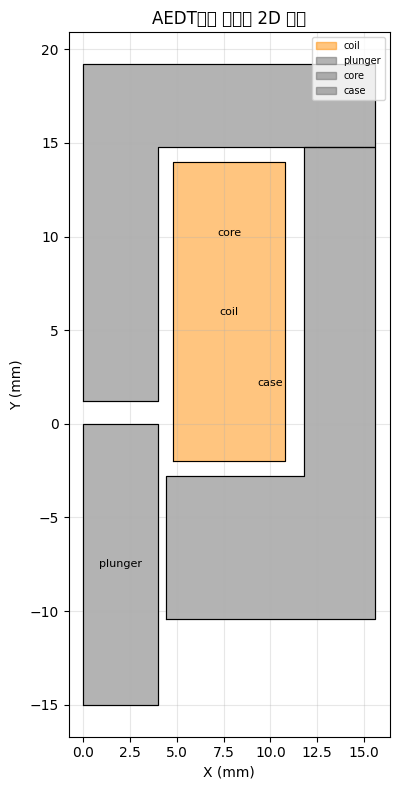

In [11]:
# AEDT에서 추출한 형상 시각화 (셀 7과 동일 방식)
import matplotlib.pyplot as plt
from moa_actuator import extract_geometry

fig, ax = plt.subplots(figsize=(5, 8))
colors = {'Coil': '#FF8C00', 'Steel': '#696969', 'Magnet': '#DC143C', 'Other': '#228B22'}

for part in design_aedt.parts:
    geom = extract_geometry(part)
    if not geom or not geom.is_valid:
        print(f"  [SKIP] {part.name} — geometry 없음 (vertices={0})")
        continue

    xs = [p.x for p in geom.points] + [geom.points[0].x]
    ys = [p.y for p in geom.points] + [geom.points[0].y]
    c = colors.get(part.kind, '#AAAAAA')
    ax.fill(xs, ys, alpha=0.5, color=c, label=part.name)
    ax.plot(xs, ys, 'k-', linewidth=0.8)
    ax.text((min(xs)+max(xs))/2, (min(ys)+max(ys))/2,
            part.name, ha='center', va='center', fontsize=8)
    print(f"  [OK]   {part.name} — {len(geom.points)} vertices")

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_title('AEDT에서 추출한 2D 형상')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()